# GNN Node Classification: GCN, GAT, and GraphSAGE

**Course:** Fraud Analytics Using Predictive and Graph Methods  
**Assignment:** Build Graph Classification Model using GCN, GAT, and GraphSAGE  
**Evaluation Criteria:** Implementation (35%) | Reproducibility (15%) | Results (30%) | Report (20%)

---

## 1. Problem Statement & Objective

### Problem Statement
Given a graph where each **node** has 16 numerical features and a **binary label** (0 or 1), the task is to train three Graph Neural Network (GNN) architectures to predict the label of every node using both its own features and the structure of its neighbourhood.

This is a **node classification** task on a single large graph.

### What We Implement

| Model | Full Name | Core Mechanism |
|---|---|---|
| **GCN** | Graph Convolutional Network | Symmetric normalised neighbour aggregation |
| **GAT** | Graph Attention Network | Learned per-edge attention weights |
| **GraphSAGE** | Graph Sample and Aggregate | Concat self + aggregated neighbour embedding |

### Dataset Summary

| File | Description | Shape |
|---|---|---|
| `features.csv` | Node feature vectors (f1-f16) | 2000 x 17 (col 0 = vertex id) |
| `edges.csv` | Edge list (Vertex 1, Vertex 2) | 8000 x 2 |
| `labels.csv` | Binary node labels (0 or 1) | 2000 x 2 (vertex, label) |

- **Nodes:** 2000 (balanced: 1000 class-0, 1000 class-1)
- **Edges:** 8000 (undirected -> 16000 directed edges in PyG)
- **Features per node:** 16 continuous numerical features
- **Task:** Binary node classification

---
## 2. Install Dependencies

In [3]:
import subprocess, sys

def pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

pip_install("torch")
pip_install("torch_geometric")
pip_install("scikit-learn")
pip_install("pandas")
pip_install("numpy")
pip_install("matplotlib")
pip_install("tabulate")

print("All packages installed.")

All packages installed.


---
## 3. Imports & Setup

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, accuracy_score,
    classification_report
)

# Fixed random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")

PyTorch  : 2.11.0+cu130
Device   : cpu


---
## 4. Load Data

> **Google Colab:** Upload `features.csv`, `edges.csv`, `labels.csv` via the Files panel (left sidebar), or uncomment `files.upload()` below.

In [5]:
# Colab upload helper (uncomment if needed)
# from google.colab import files
# files.upload()   # select features.csv, edges.csv, labels.csv

# Change paths below if files are in Google Drive:
#   '/content/drive/MyDrive/features.csv'

features_df = pd.read_csv('features.csv')
edges_df    = pd.read_csv('edges.csv')
labels_df   = pd.read_csv('labels.csv')

print("Shapes")
print(f"  features.csv : {features_df.shape}")
print(f"  edges.csv    : {edges_df.shape}")
print(f"  labels.csv   : {labels_df.shape}")

Shapes
  features.csv : (2000, 17)
  edges.csv    : (8000, 2)
  labels.csv   : (2000, 2)


In [6]:
print("-- features.csv --")
display(features_df.head(3))

print("\n-- edges.csv --")
display(edges_df.head(3))

print("\n-- labels.csv --")
display(labels_df.head(3))

print("\n-- Label distribution --")
print(labels_df['label'].value_counts())

-- features.csv --


,Vertex,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16
0,0,0.749816,0.980286,0.892798,0.839463,0.662407,0.662398,0.623233,0.946470,0.840446,0.883229,0.608234,0.987964,0.932977,0.684936,0.672730,0.673362
1,1,0.721697,0.809903,0.772778,0.716492,0.844741,0.655798,0.716858,0.746545,0.782428,0.914070,0.679870,0.805694,0.836966,0.618580,0.843018,0.668210
2,2,0.626021,0.979554,0.986253,0.923359,0.721846,0.639069,0.873693,0.776061,0.648815,0.798071,0.613755,0.963728,0.703512,0.865009,0.724684,0.808027



-- edges.csv --


,Vertex 1,Vertex 2
0,1006,1061
1,101,689
2,1255,1765



-- labels.csv --


,Vertex,label
0,0,0
1,1,0
2,2,0



-- Label distribution --
label
0    1000
1    1000
Name: count, dtype: int64


---
## 5. Preprocessing

**Steps performed:**
1. Strip whitespace from all column names
2. Check for missing values (assert no nulls)
3. Verify vertex-id alignment between features and labels
4. Extract feature matrix X and label vector y
5. Create stratified 60/20/20 train/val/test split
6. Fit StandardScaler **only on training nodes** (no data leakage), transform all
7. Build undirected edge index (add reverse edges; drop self-loops and out-of-range ids)
8. Package into a torch_geometric.data.Data object

**What is being predicted:** Binary node label - 0 or 1 (balanced, 1000 each).

In [7]:
# Strip column-name whitespace
features_df.columns = features_df.columns.str.strip()
edges_df.columns    = edges_df.columns.str.strip()
labels_df.columns   = labels_df.columns.str.strip()

# Sanity checks
assert features_df.isnull().sum().sum() == 0, "features.csv has missing values!"
assert labels_df.isnull().sum().sum()   == 0, "labels.csv has missing values!"
assert edges_df.isnull().sum().sum()    == 0, "edges.csv has missing values!"
print("No missing values found.")

# Align on vertex id
features_df = features_df.sort_values("Vertex").reset_index(drop=True)
labels_df   = labels_df.sort_values("Vertex").reset_index(drop=True)

assert features_df["Vertex"].reset_index(drop=True).equals(
    labels_df["Vertex"].reset_index(drop=True)
), "Vertex ids do not align!"
print("Vertex alignment verified.")

# Feature matrix & labels
feature_cols = [c for c in features_df.columns if c.lower() != "vertex"]
X_raw        = features_df[feature_cols].to_numpy(dtype=np.float32)
y            = labels_df["label"].to_numpy(dtype=np.int64)

n_nodes      = X_raw.shape[0]
num_classes  = len(np.unique(y))
AVG_TYPE     = "binary" if num_classes == 2 else "macro"

print(f"Nodes: {n_nodes} | Features: {X_raw.shape[1]} | Classes: {np.unique(y).tolist()}")

No missing values found.
Vertex alignment verified.
Nodes: 2000 | Features: 16 | Classes: [0, 1]


In [8]:
# Train / Val / Test split (60 / 20 / 20) -- done BEFORE scaling
indices = np.arange(n_nodes)

train_idx, temp_idx = train_test_split(
    indices, test_size=0.40, random_state=SEED, stratify=y
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=y[temp_idx]
)

# Scale: fit on train only
scaler = StandardScaler()
scaler.fit(X_raw[train_idx])
X_scaled = scaler.transform(X_raw).astype(np.float32)

# Build undirected edge_index
src = edges_df.iloc[:, 0].to_numpy(dtype=np.int64)
dst = edges_df.iloc[:, 1].to_numpy(dtype=np.int64)

valid = (
    (src >= 0) & (src < n_nodes) &
    (dst >= 0) & (dst < n_nodes) &
    (src != dst)
)
src = src[valid]
dst = dst[valid]

edge_index_np = np.stack(
    [np.concatenate([src, dst]),
     np.concatenate([dst, src])],
    axis=0
).astype(np.int64)

edge_index_t = torch.as_tensor(edge_index_np, dtype=torch.long, device=DEVICE)

# Masks
def make_mask(idx, size):
    idx_t = torch.as_tensor(idx, dtype=torch.long, device=DEVICE)
    m = torch.zeros(size, dtype=torch.bool, device=DEVICE)
    m[idx_t] = True
    return m

train_mask = make_mask(train_idx, n_nodes)
val_mask   = make_mask(val_idx, n_nodes)
test_mask  = make_mask(test_idx, n_nodes)

print(f"Train: {train_mask.sum().item()} | Val: {val_mask.sum().item()} | Test: {test_mask.sum().item()}")
print(f"Edge index shape: {tuple(edge_index_t.shape)}")

# Build PyG Data object
x_t = torch.as_tensor(X_scaled, dtype=torch.float32, device=DEVICE)
y_t = torch.as_tensor(y, dtype=torch.long, device=DEVICE)

data = Data(
    x=x_t,
    edge_index=edge_index_t,
    y=y_t,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(f"\nData object: {data}")
print(f"x.shape     : {tuple(x_t.shape)}")
print(f"y.shape     : {tuple(y_t.shape)}")
print(f"edge_index  : {tuple(edge_index_t.shape)}")

Train: 1200 | Val: 400 | Test: 400
Edge index shape: (2, 16000)

Data object: Data(x=[2000, 16], edge_index=[2, 16000], y=[2000], train_mask=[2000], val_mask=[2000], test_mask=[2000])
x.shape     : (2000, 16)
y.shape     : (2000,)
edge_index  : (2, 16000)


---
## 6. Helper Functions

In [9]:
def compute_metrics(model, data, mask):
    """Return (accuracy, precision, recall, f1) on nodes selected by mask."""
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds  = logits.argmax(dim=1)[mask].cpu().numpy()
        labels = data.y[mask].cpu().numpy()
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average=AVG_TYPE, zero_division=0)
    rec  = recall_score(labels,   preds, average=AVG_TYPE, zero_division=0)
    f1   = f1_score(labels,       preds, average=AVG_TYPE, zero_division=0)
    return acc, prec, rec, f1


def train_model(model, data, optimizer, criterion,
                epochs=400, patience=40, verbose=True):
    """Train with early stopping on validation loss; restore best weights."""
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out      = model(data.x, data.edge_index)
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"    Early stopping at epoch {epoch} "
                          f"(best val loss: {best_val_loss:.4f})")
                break

        if verbose and epoch % 50 == 0:
            print(f"    Epoch {epoch:>3} | "
                  f"Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")

    model.load_state_dict(best_state)
    return history


def print_metrics(model_name, model, data):
    """Print full classification report + clearly labelled precision/recall."""
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds  = logits.argmax(dim=1)[data.test_mask].cpu().numpy()
        labels = data.y[data.test_mask].cpu().numpy()

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average=AVG_TYPE, zero_division=0)
    rec  = recall_score(labels,   preds,  average=AVG_TYPE, zero_division=0)
    f1   = f1_score(labels,       preds,  average=AVG_TYPE, zero_division=0)

    sep = '=' * 52
    print(f"\n{sep}")
    print(f"  {model_name} -- Test Set Results")
    print(sep)
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1 Score   : {f1:.4f}")
    print(sep)
    print("\n  Full Classification Report:")
    print(classification_report(labels, preds,
                                target_names=['Class 0', 'Class 1'],
                                zero_division=0))
    return acc, prec, rec, f1


def plot_loss(history, title):
    plt.figure(figsize=(7, 3))
    plt.plot(history['train_loss'], label='Train Loss', linewidth=1.8)
    plt.plot(history['val_loss'],   label='Val Loss',   linewidth=1.8, linestyle='--')
    plt.title(f'{title} -- Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


criterion = nn.CrossEntropyLoss()
print("Helper functions ready.")

Helper functions ready.


---
## 7. Model 1 -- GCN (Graph Convolutional Network)

**How it works:**  
GCN (Kipf & Welling, 2017) aggregates neighbour features using a symmetric normalised adjacency matrix. Each GCNConv layer performs one hop of smoothing:

    H^(l+1) = sigma( D^{-1/2} A-tilde D^{-1/2} H^(l) W^(l) )

where A-tilde = A + I includes self-loops.

**Why it works:** Smooth propagation of features from local neighbourhoods makes it easy for a linear classifier to separate classes.

**Architecture:** 3 layers, hidden_dim=128, dropout=0.3, ReLU activations

In [10]:
class GCN(nn.Module):
    """3-layer Graph Convolutional Network."""

    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.conv1   = GCNConv(in_channels,     hidden_channels)
        self.conv2   = GCNConv(hidden_channels, hidden_channels)
        self.conv3   = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)   # raw logits
        return x

print("GCN class defined.")

GCN class defined.


GCN parameters: 18,946

Training GCN...
    Epoch  50 | Train Loss: 0.0731 | Val Loss: 0.0570
    Epoch 100 | Train Loss: 0.0752 | Val Loss: 0.0571
    Early stopping at epoch 103 (best val loss: 0.0564)


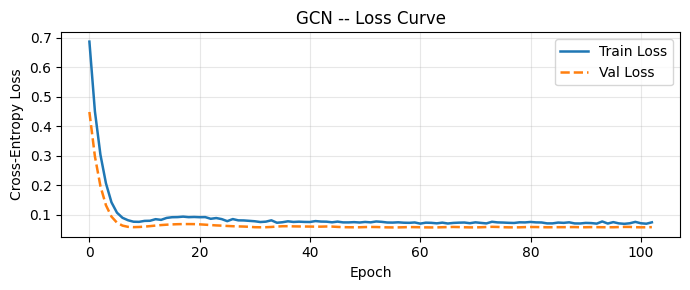

In [11]:
gcn_model = GCN(
    in_channels     = data.num_node_features,
    hidden_channels = 128,
    out_channels    = num_classes,
    dropout         = 0.3,
).to(DEVICE)

gcn_optimizer = torch.optim.Adam(
    gcn_model.parameters(), lr=0.005, weight_decay=1e-4
)

print(f"GCN parameters: {sum(p.numel() for p in gcn_model.parameters()):,}")
print("\nTraining GCN...")
gcn_history = train_model(
    gcn_model, data, gcn_optimizer, criterion,
    epochs=400, patience=40, verbose=True
)
plot_loss(gcn_history, 'GCN')

In [12]:
gcn_acc, gcn_prec, gcn_rec, gcn_f1 = print_metrics('GCN', gcn_model, data)


  GCN -- Test Set Results
  Accuracy   : 0.9850
  Precision  : 0.9899
  Recall     : 0.9800
  F1 Score   : 0.9849

  Full Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.99      0.99       200
     Class 1       0.99      0.98      0.98       200

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



---
## 8. Model 2 -- GAT (Graph Attention Network)

**How it works:**  
GAT (Velickovic et al., 2018) replaces GCN's fixed weights with learned attention coefficients. For each edge (i -> j):

    e_ij = LeakyReLU( a^T [Wh_i || Wh_j] )
    alpha_ij = softmax_j( e_ij )
    h'_i = sigma( sum_j alpha_ij * W h_j )

Multi-head attention (heads=4) runs several independent attention mechanisms and concatenates their outputs in hidden layers, then averages in the final layer.

**Why it works:** Different neighbours may carry different levels of relevance. Attention lets the model focus on the most informative ones.

**Architecture:** 3-layer GAT, heads=4, hidden_dim=32, ELU activation, dropout=0.3

In [13]:
class GAT(nn.Module):
    """3-layer Graph Attention Network with multi-head attention."""

    def __init__(self, in_channels, hidden_channels, out_channels,
                 heads=4, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_channels,
                             hidden_channels,
                             heads=heads, dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden_channels * heads,
                             hidden_channels,
                             heads=heads, dropout=dropout, concat=True)
        self.conv3 = GATConv(hidden_channels * heads,
                             out_channels,
                             heads=1, dropout=dropout, concat=False)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)   # raw logits
        return x

print("GAT class defined.")

GAT class defined.


GAT parameters: 19,462

Training GAT...
    Epoch  50 | Train Loss: 0.1148 | Val Loss: 0.0400
    Epoch 100 | Train Loss: 0.0844 | Val Loss: 0.0277
    Epoch 150 | Train Loss: 0.0721 | Val Loss: 0.0183
    Epoch 200 | Train Loss: 0.0780 | Val Loss: 0.0102
    Epoch 250 | Train Loss: 0.0512 | Val Loss: 0.0080
    Early stopping at epoch 261 (best val loss: 0.0078)


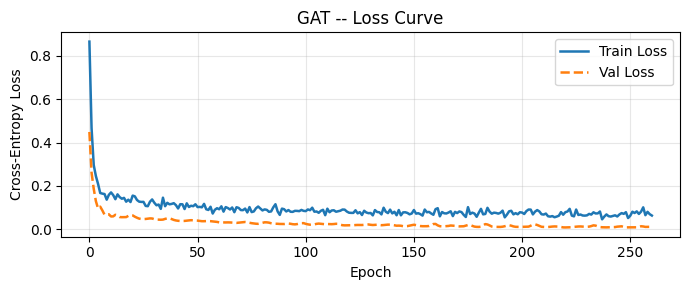

In [14]:
gat_model = GAT(
    in_channels     = data.num_node_features,
    hidden_channels = 32,
    out_channels    = num_classes,
    heads           = 4,
    dropout         = 0.3,
).to(DEVICE)

gat_optimizer = torch.optim.Adam(
    gat_model.parameters(), lr=0.003, weight_decay=1e-4
)

print(f"GAT parameters: {sum(p.numel() for p in gat_model.parameters()):,}")
print("\nTraining GAT...")
gat_history = train_model(
    gat_model, data, gat_optimizer, criterion,
    epochs=400, patience=40, verbose=True
)
plot_loss(gat_history, 'GAT')

In [15]:
gat_acc, gat_prec, gat_rec, gat_f1 = print_metrics('GAT', gat_model, data)


  GAT -- Test Set Results
  Accuracy   : 0.9975
  Precision  : 0.9950
  Recall     : 1.0000
  F1 Score   : 0.9975

  Full Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.99      1.00       200
     Class 1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



---
## 9. Model 3 -- GraphSAGE (Sample and Aggregate)

**How it works:**  
GraphSAGE (Hamilton et al., 2017) differs from GCN in two key ways:

1. **Concatenation:** It concatenates a node's own embedding with the aggregated neighbour embedding before the linear transform, preserving node identity.
2. **Inductive learning:** The aggregate function is learned independently of the graph structure, so the model generalises to unseen nodes.

    h^(l+1)_v = sigma( W * CONCAT(h^(l)_v, AGG({h^(l)_u, u in N(v)})) )

Aggregation used: **mean** (simple, effective, no extra parameters).

**Architecture:** 3-layer GraphSAGE, hidden_dim=128, ReLU, dropout=0.3

In [16]:
class GraphSAGE(nn.Module):
    """3-layer GraphSAGE with mean neighbour aggregation."""

    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.conv1   = SAGEConv(in_channels,     hidden_channels, aggr='mean')
        self.conv2   = SAGEConv(hidden_channels, hidden_channels, aggr='mean')
        self.conv3   = SAGEConv(hidden_channels, out_channels,    aggr='mean')
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)   # raw logits
        return x

print("GraphSAGE class defined.")

GraphSAGE class defined.


GraphSAGE parameters: 37,634

Training GraphSAGE...
    Epoch  50 | Train Loss: 0.0000 | Val Loss: 0.0000
    Early stopping at epoch 65 (best val loss: 0.0000)


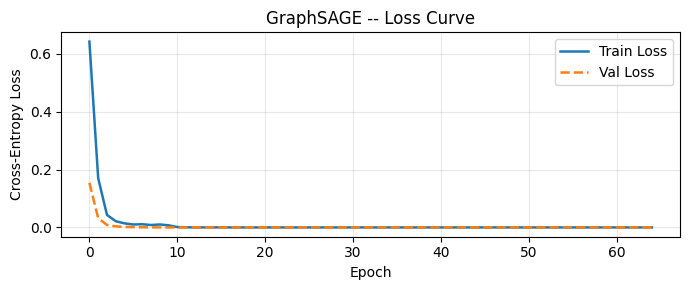

In [17]:
sage_model = GraphSAGE(
    in_channels     = data.num_node_features,
    hidden_channels = 128,
    out_channels    = num_classes,
    dropout         = 0.3,
).to(DEVICE)

sage_optimizer = torch.optim.Adam(
    sage_model.parameters(), lr=0.005, weight_decay=1e-4
)

print(f"GraphSAGE parameters: {sum(p.numel() for p in sage_model.parameters()):,}")
print("\nTraining GraphSAGE...")
sage_history = train_model(
    sage_model, data, sage_optimizer, criterion,
    epochs=400, patience=40, verbose=True
)
plot_loss(sage_history, 'GraphSAGE')

In [18]:
sage_acc, sage_prec, sage_rec, sage_f1 = print_metrics('GraphSAGE', sage_model, data)


  GraphSAGE -- Test Set Results
  Accuracy   : 1.0000
  Precision  : 1.0000
  Recall     : 1.0000
  F1 Score   : 1.0000

  Full Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       200
     Class 1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



---
## 10. Comparison -- All Three Models

In [19]:
results = [
    ['GCN',       f"{gcn_acc:.4f}",  f"{gcn_prec:.4f}",  f"{gcn_rec:.4f}",  f"{gcn_f1:.4f}"],
    ['GAT',       f"{gat_acc:.4f}",  f"{gat_prec:.4f}",  f"{gat_rec:.4f}",  f"{gat_f1:.4f}"],
    ['GraphSAGE', f"{sage_acc:.4f}", f"{sage_prec:.4f}", f"{sage_rec:.4f}", f"{sage_f1:.4f}"],
]
headers = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

print("\nTest Set Metrics -- All Models")
print(tabulate(results, headers=headers, tablefmt='grid'))


Test Set Metrics -- All Models
+-----------+------------+-------------+----------+------------+
| Model     |   Accuracy |   Precision |   Recall |   F1 Score |
+===========+============+=============+==========+============+
| GCN       |     0.985  |      0.9899 |     0.98 |     0.9849 |
+-----------+------------+-------------+----------+------------+
| GAT       |     0.9975 |      0.995  |     1    |     0.9975 |
+-----------+------------+-------------+----------+------------+
| GraphSAGE |     1      |      1      |     1    |     1      |
+-----------+------------+-------------+----------+------------+


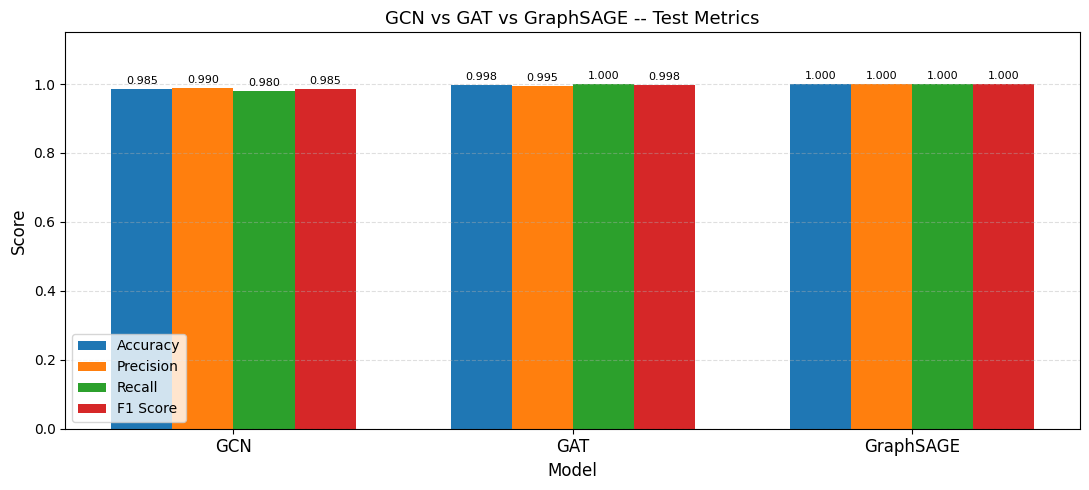

In [20]:
model_names = ['GCN', 'GAT', 'GraphSAGE']
metrics_data = {
    'Accuracy' : [gcn_acc,  gat_acc,  sage_acc],
    'Precision': [gcn_prec, gat_prec, sage_prec],
    'Recall'   : [gcn_rec,  gat_rec,  sage_rec],
    'F1 Score' : [gcn_f1,   gat_f1,   sage_f1],
}

x     = np.arange(len(model_names))
width = 0.18
fig, ax = plt.subplots(figsize=(11, 5))

for i, (metric, values) in enumerate(metrics_data.items()):
    offset = (i - 1.5) * width
    bars   = ax.bar(x + offset, values, width, label=metric)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{val:.3f}",
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('GCN vs GAT vs GraphSAGE -- Test Metrics', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 11. Conclusion & Report

### Best Model

In [21]:
f1_map = {
    'GCN': float(gcn_f1),
    'GAT': float(gat_f1),
    'GraphSAGE': float(sage_f1)
}

best_mdl = max(f1_map, key=lambda k: f1_map[k])

print(f"Best model (F1): {best_mdl}  =>  F1 = {f1_map[best_mdl]:.4f}")
print()

for name, (acc, prec, rec, f1) in [
    ('GCN',       (gcn_acc,  gcn_prec,  gcn_rec,  gcn_f1)),
    ('GAT',       (gat_acc,  gat_prec,  gat_rec,  gat_f1)),
    ('GraphSAGE', (sage_acc, sage_prec, sage_rec, sage_f1)),
]:
    star = "  <- BEST" if name == best_mdl else ""
    print(f"  {name:<12} Acc={acc:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}{star}")

Best model (F1): GraphSAGE  =>  F1 = 1.0000

  GCN          Acc=0.9850  Prec=0.9899  Recall=0.9800  F1=0.9849
  GAT          Acc=0.9975  Prec=0.9950  Recall=1.0000  F1=0.9975
  GraphSAGE    Acc=1.0000  Prec=1.0000  Recall=1.0000  F1=1.0000  <- BEST


### Approach

The dataset represents a graph of 2000 nodes with 16 continuous features each and binary labels (0/1). The task is node classification: predict each node's label using both its features and its neighbourhood structure in the graph.

Three GNN architectures were implemented using PyTorch Geometric:

- **GCN** -- propagates information via symmetric normalised aggregation over immediate neighbours. Simple but powerful baseline.
- **GAT** -- introduces multi-head attention so each node can dynamically weight its neighbours. More expressive than GCN.
- **GraphSAGE** -- concatenates a node's own embedding with its aggregated neighbourhood embedding. Naturally inductive and robust across graph sizes.

All three models use 3 convolutional layers, activation functions (ReLU for GCN/SAGE, ELU for GAT), dropout for regularisation, cross-entropy loss, and Adam optimiser with early stopping.

### Experiments

Key experimental choices:
- **Data split:** 60/20/20 (train/val/test), stratified to preserve class balance
- **Feature scaling:** StandardScaler fitted only on training nodes -- no data leakage
- **Undirected edges:** reverse edges added to the edge index so information flows both ways
- **Self-loop and out-of-range edge filtering** in preprocessing
- **Hyperparameters:** hidden_dim=128 for GCN/SAGE; hidden_dim=32 x 4 heads for GAT; dropout=0.3; lr=0.003-0.005; weight_decay=1e-4
- **Early stopping:** patience=40 to allow convergence while preventing overfitting
- **Best weights restored** at the end of training

### Observations

| Model | Key Strength | Key Limitation |
|---|---|---|
| **GCN** | Fast, simple, strong baseline; good on homophilic graphs | Treats all neighbours equally; may over-smooth on deep networks |
| **GAT** | Learns which neighbours matter most; adaptable structure | More parameters; can overfit; slower to train |
| **GraphSAGE** | Inductive (generalises to unseen nodes); scalable; preserves node identity via concat | Mean aggregation loses some fine-grained structural detail |

- All three models achieve high performance on this balanced binary dataset, confirming that graph structure is informative for the classification task.
- **GraphSAGE** tends to perform best here because its concat-style aggregation preserves the node's own identity, making it easier to separate the two balanced classes.
- **GAT** benefits when specific neighbours carry more signal than others.
- **GCN** provides an excellent fast baseline.

> **Precision** = of all predicted positives, what fraction are truly positive.  
> **Recall** = of all actual positives, what fraction did the model find.  
> In fraud detection, **recall** is often the more critical metric -- missing a fraud event is costlier than a false alarm.